<a href="https://www.kaggle.com/code/dmitryvokhmin/project-3-dmitry?scriptVersionId=226671620" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re

# импортируем библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

# Загружаем специальный удобный инструмент для разделения датасета:
from sklearn.model_selection import train_test_split

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sf-booking/hotels_test.csv
/kaggle/input/sf-booking/hotels_train.csv
/kaggle/input/sf-booking/submission.csv


In [2]:
# всегда фиксируйте RANDOM_SEED, чтобы ваши эксперименты были воспроизводимы!
RANDOM_SEED = 42

In [3]:
# зафиксируем версию пакетов, чтобы эксперименты были воспроизводимы:
!pip freeze > requirements.txt

In [4]:
# Подгрузим наши данные из соревнования

DATA_DIR = '/kaggle/input/sf-booking/'
df_train = pd.read_csv(DATA_DIR+'/hotels_train.csv') # датасет для обучения
df_test = pd.read_csv(DATA_DIR+'hotels_test.csv') # датасет для предсказания
sample_submission = pd.read_csv(DATA_DIR+'/submission.csv') # самбмишн

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

In [6]:
df_train.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               128935 non-null  object 
 1   additional_number_of_scoring                128935 non-null  int64  
 2   review_date                                 128935 non-null  object 
 3   average_score                               128935 non-null  float64
 4   hotel_name                                  128935 non-null  object 
 5   reviewer_nationality                        128935 non-null  object 
 6   negative_review                             128935 non-null  object 
 7   review_total_negative_word_counts           128935 non-null  int64  
 8   total_number_of_reviews                     128935 non-null  int64  
 9   positive_review                             128935 non-null  object 
 

In [8]:
df_test.head(2)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443


In [9]:
sample_submission.head(2)

,reviewer_score,id
0,1,488440
1,10,274649


In [10]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128935 entries, 0 to 128934
Data columns (total 2 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   reviewer_score  128935 non-null  int64
 1   id              128935 non-null  int64
dtypes: int64(2)
memory usage: 2.0 MB


# 1. Очистка данных

In [11]:
print("Duplicates:", df_train[df_train.duplicated()].shape[0])
df_train.drop_duplicates(inplace=True)
print("Duplicates after cleaning:", df_train[df_train.duplicated()].shape[0])

Duplicates: 307
Duplicates after cleaning: 0


In [12]:
# ВАЖНО! дря корректной обработки признаков объединяем трейн и тест в один датасет
df_train['sample'] = 1 # помечаем где у нас трейн
df_test['sample'] = 0 # помечаем где у нас тест
df_test['reviewer_score'] = 0 # в тесте у нас нет значения reviewer_score, мы его должны предсказать, по этому пока просто заполняем нулями

data = df_test.append(df_train, sort=False).reset_index(drop=True) # объединяем

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [14]:
missing_addresses = {
    'W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria': {'lat': 48.2198, 'lng': 16.3578},
    'Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria': {'lat': 48.2245, 'lng': 16.3570},
    '23 Rue Damr mont 18th arr 75018 Paris France': {'lat': 48.8895, 'lng': 2.3332},
    'Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria': {'lat': 48.2098, 'lng': 16.3499},
    'Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria': {'lat': 48.2145, 'lng': 16.3820},
    'Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria': {'lat': 48.2100, 'lng': 16.3475},
    'Bail n 4 6 Eixample 08010 Barcelona Spain': {'lat': 41.3896, 'lng': 2.1756},
    'Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria': {'lat': 48.1920, 'lng': 16.3955},
    '4 rue de la P pini re 8th arr 75008 Paris France': {'lat': 48.8770, 'lng': 2.3175},
    '20 Rue De La Ga t 14th arr 75014 Paris France': {'lat': 48.8415, 'lng': 2.3240},
    'W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria': {'lat': 48.2170, 'lng': 16.3595},
    'Savoyenstra e 2 16 Ottakring 1160 Vienna Austria': {'lat': 48.2110, 'lng': 16.3085},
    'Pau Clar s 122 Eixample 08009 Barcelona Spain': {'lat': 41.3925, 'lng': 2.1670},
    'Sieveringer Stra e 4 19 D bling 1190 Vienna Austria': {'lat': 48.2455, 'lng': 16.3400},
    'Paragonstra e 1 11 Simmering 1110 Vienna Austria': {'lat': 48.1535, 'lng': 16.4430},
    'Hasenauerstra e 12 19 D bling 1190 Vienna Austria': {'lat': 48.2330, 'lng': 16.3445},
    'Sep lveda 180 Eixample 08011 Barcelona Spain': {'lat': 41.3820, 'lng': 2.1575}
}

missing_data = pd.DataFrame.from_dict(missing_addresses, orient='index').reset_index()
missing_data.columns = ['hotel_address', 'lat', 'lng']

data = data.merge(missing_data, how="left", on='hotel_address', suffixes=(None, '_missing'))
data['lat'] = data['lat'].combine_first(data['lat_missing'])
data['lng'] = data['lat'].combine_first(data['lng_missing'])

data.drop(columns=['lat_missing', 'lng_missing'], inplace=True)

data.isna().sum()

hotel_address                                 0
additional_number_of_scoring                  0
review_date                                   0
average_score                                 0
hotel_name                                    0
reviewer_nationality                          0
negative_review                               0
review_total_negative_word_counts             0
total_number_of_reviews                       0
positive_review                               0
review_total_positive_word_counts             0
total_number_of_reviews_reviewer_has_given    0
tags                                          0
days_since_review                             0
lat                                           0
lng                                           0
sample                                        0
reviewer_score                                0
dtype: int64

# 2. Иследование данных

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 515431 entries, 0 to 515430
Data columns (total 18 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               515431 non-null  object 
 1   additional_number_of_scoring                515431 non-null  int64  
 2   review_date                                 515431 non-null  object 
 3   average_score                               515431 non-null  float64
 4   hotel_name                                  515431 non-null  object 
 5   reviewer_nationality                        515431 non-null  object 
 6   negative_review                             515431 non-null  object 
 7   review_total_negative_word_counts           515431 non-null  int64  
 8   total_number_of_reviews                     515431 non-null  int64  
 9   positive_review                             515431 non-null  object 
 

In [16]:
data.describe(include='all')

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,tags,days_since_review,lat,lng,sample,reviewer_score
count,515431,515431.000000,515431,515431.000000,515431,515431,515431,515431.000000,515431.000000,515431,515431.000000,515431.000000,515431,515431,515431.000000,515431.000000,515431.00000,515431.000000
unique,1493,NaN,731,NaN,1492,227,330011,NaN,NaN,412601,NaN,NaN,55242,731,NaN,NaN,NaN,NaN
top,163 Marsh Wall Docklands Tower Hamlets London ...,NaN,8/2/2017,NaN,Britannia International Hotel Canary Wharf,United Kingdom,No Negative,NaN,NaN,No Positive,NaN,NaN,"[' Leisure trip ', ' Couple ', ' Double Room '...",1 days,NaN,NaN,NaN,NaN
freq,4789,NaN,2584,NaN,4789,245165,127816,NaN,NaN,35924,NaN,NaN,5101,2584,NaN,NaN,NaN,NaN
mean,NaN,498.275079,NaN,8.397630,NaN,NaN,NaN,18.539760,2744.259084,NaN,17.777342,7.165215,NaN,NaN,49.432742,49.432742,0.74985,6.296715
std,NaN,500.618961,NaN,0.548033,NaN,NaN,NaN,29.690973,2317.823718,NaN,21.803204,11.038742,NaN,NaN,3.461235,3.461235,0.43310,3.902967
min,NaN,1.000000,NaN,5.200000,NaN,NaN,NaN,0.000000,43.000000,NaN,0.000000,1.000000,NaN,NaN,41.328376,41.328376,0.00000,0.000000
25%,NaN,169.000000,NaN,8.100000,NaN,NaN,NaN,2.000000,1161.000000,NaN,5.000000,1.000000,NaN,NaN,48.214277,48.214277,0.00000,0.000000
50%,NaN,342.000000,NaN,8.400000,NaN,NaN,NaN,9.000000,2134.000000,NaN,11.000000,3.000000,NaN,NaN,51.499981,51.499981,1.00000,7.900000
75%,NaN,660.000000,NaN,8.800000,NaN,NaN,NaN,23.000000,3633.000000,NaN,22.000000,8.000000,NaN,NaN,51.516288,51.516288,1.00000,9.600000


## hotel_address - адрес отеля

In [17]:
data['hotel_address'].apply(lambda x: str(x.split()[-2:])).value_counts()

['United', 'Kingdom']           262300
['Barcelona', 'Spain']           60149
['Paris', 'France']              59626
['Amsterdam', 'Netherlands']     57212
['Vienna', 'Austria']            38938
['Milan', 'Italy']               37206
Name: hotel_address, dtype: int64

Вынесение страны скорей всего сможет помочь в более точном обучение модели

## additional_number_of_scoring - есть также некоторые гости, которые просто поставили оценку сервису, а не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.

In [18]:
data['additional_number_of_scoring'].head(5)

0    904
1    612
2     46
3    241
4    834
Name: additional_number_of_scoring, dtype: int64

Скорей всего будет высоко корелировать с общем количество отзывов

## review_date - дата, когда рецензент разместил соответствующий отзыв

In [19]:
data['review_date'] = pd.to_datetime(data['review_date'])

Скорей всего будет полезно вынести месяц, сезон и год отдельные признаки.

## average_score - средний балл отеля, рассчитанный на основе последнего комментария за последний год

Скорей всего важный признак отображающий среднее мнение людей об отеле

## hotel_name - название отеля

Не думаю что имя отеля может быть полезно

## reviewer_nationality - национальность рецензента

Скорей всего будет полезно перевести этот признак в числовой формат и посмотреть как национальность влияет на отзывы. Так же может хорошо работать в сочетание с со страной отеля

## negative_review - отрицательный отзыв, который рецензент дал отелю.

In [20]:
data['negative_review'].describe()

count          515431
unique         330011
top       No Negative
freq           127816
Name: negative_review, dtype: object

Видно что если в отзыве человека нет негативной части то поле заполнено значение No Negative. Возможно стоить перевести это в бинарное значение

## review_total_negative_word_counts - общее количество слов в отрицательном отзыв

## total_number_of_reviews - общее количество действительных отзывов об отеле

## positive_review - положительный отзыв, который рецензент дал отелю

In [21]:
data['positive_review'].describe()

count          515431
unique         412601
top       No Positive
freq            35924
Name: positive_review, dtype: object

Видно что если в отзыве человека нет позитивной части то поле заполнено значение No Positive. Возможно стоить перевести это в бинарное значение

## total_number_of_reviews_reviewer_has_given - количество отзывов, которые рецензенты дали в прошлом

## tags - теги, которые рецензент дал отелю.

In [22]:
data['tags'][0]

"[' Leisure trip ', ' Couple ', ' Double Room ', ' Stayed 2 nights ']"

Возможно можно вынести в отдельные признаки количество ночей, типо поездки и тип комнаты

## days_since_review - продолжительность между датой проверки и датой очистки

## lat - широта отеля

## lng - долгота отеля

# 3. Создание новых признаков

In [23]:
# Создадим новые признаки для месяца, сезона и года
data['review_year'] = data['review_date'].dt.year
data['review_month'] = data['review_date'].dt.month
data['review_quarter'] = data['review_date'].dt.quarter

In [24]:
# Создадим новый признак для страны
data['hotel_country'] = data['hotel_address'].apply(lambda x: " ".join(x.split()[-2:]) if x.split()[-1] == 'Kingdom' else x.split()[-1])

In [25]:
# Создадим бинарный признак для отзывов без негативной части
data['no_negative'] = data['negative_review'].apply(lambda x: int(x == 'No Negative'))

In [26]:
# Создадим бинарный признак для отзывов без позитивной части
data['no_positive'] = data['positive_review'].apply(lambda x: int(x == 'No Positive'))

In [27]:
# Создадим новый признак для количества ночей которое люди остаются в отеле
def fetch_night(tags):
    regex_pattern = r'Stayed'
    tag_list = eval(tags)
    for tag in tag_list:
        if re.search(regex_pattern, tag):
            return int(tag.split()[1])
    
data['nights'] = data['tags'].apply(fetch_night)

In [28]:
print('Missing nights: ', data[data['nights'].isna()].shape[0])
data['nights'].fillna(data['nights'].median(), inplace=True)
data.isna().sum()

Missing nights:  192


hotel_address                                 0
additional_number_of_scoring                  0
review_date                                   0
average_score                                 0
hotel_name                                    0
reviewer_nationality                          0
negative_review                               0
review_total_negative_word_counts             0
total_number_of_reviews                       0
positive_review                               0
review_total_positive_word_counts             0
total_number_of_reviews_reviewer_has_given    0
tags                                          0
days_since_review                             0
lat                                           0
lng                                           0
sample                                        0
reviewer_score                                0
review_year                                   0
review_month                                  0
review_quarter                          

In [29]:
# Создадим новый признак для типа поездки
def fetch_trip_type(tags):
    regex_pattern = r'trip'
    tag_list = eval(tags)
    for tag in tag_list:
        if re.search(regex_pattern, tag):
            return tag.split()[0]
    return 'Leisure'
    
data['trip_type'] = data['tags'].apply(fetch_trip_type)

## Новые признаки

1. review_year - год отзыва
2. review_month - месяц отзыва
3. review_quater - квотер отзыва
4. hotel_country - страна в которой находится отель
5. no_negative - отсутствие негативных отзывов
6. no_positive - отсутствие позитивных отзывов
7. nights - количество ночей на которое остановился посетитель
8. trip_type - тип поездки (бизнес/персональная)

# 4. Преобразование признаков

In [30]:
# Создадим числовой признак для days_since_review
data['days_since_review'] = data['days_since_review'].apply(lambda x: int(x.split()[0]))

In [31]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

data['neg_scores'] = data['negative_review'].apply(sia.polarity_scores)
data['pos_scores'] = data['positive_review'].apply(sia.polarity_scores)

data['neg_neg'] = data['neg_scores'].apply(lambda x: x['neg'])
data['neu_neg'] = data['neg_scores'].apply(lambda x: x['neu'])
data['pos_neg'] = data['neg_scores'].apply(lambda x: x['pos'])
data['compound_neg'] = data['neg_scores'].apply(lambda x: x['compound'])

data['neg_pos'] = data['pos_scores'].apply(lambda x: x['neg'])
data['neu_pos'] = data['pos_scores'].apply(lambda x: x['neu'])
data['pos_pos'] = data['pos_scores'].apply(lambda x: x['pos'])
data['compound_pos'] = data['pos_scores'].apply(lambda x: x['compound'])

/opt/conda/lib/python3.7/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 515431 entries, 0 to 515430
Data columns (total 36 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   hotel_address                               515431 non-null  object        
 1   additional_number_of_scoring                515431 non-null  int64         
 2   review_date                                 515431 non-null  datetime64[ns]
 3   average_score                               515431 non-null  float64       
 4   hotel_name                                  515431 non-null  object        
 5   reviewer_nationality                        515431 non-null  object        
 6   negative_review                             515431 non-null  object        
 7   review_total_negative_word_counts           515431 non-null  int64         
 8   total_number_of_reviews                     515431 non-null  int64        

In [33]:
import category_encoders as ce 

ord_encoder = ce.OrdinalEncoder()

data_bin = ord_encoder.fit_transform(data[['trip_type', 'hotel_country', 'reviewer_nationality']])

cols = [col for col in data.columns if data[col].dtype == 'object']
cols.append('review_date')
data.drop(columns=cols, inplace=True)

data = pd.concat([data, data_bin], axis=1)

# 5. Отбор признаков

<AxesSubplot:>

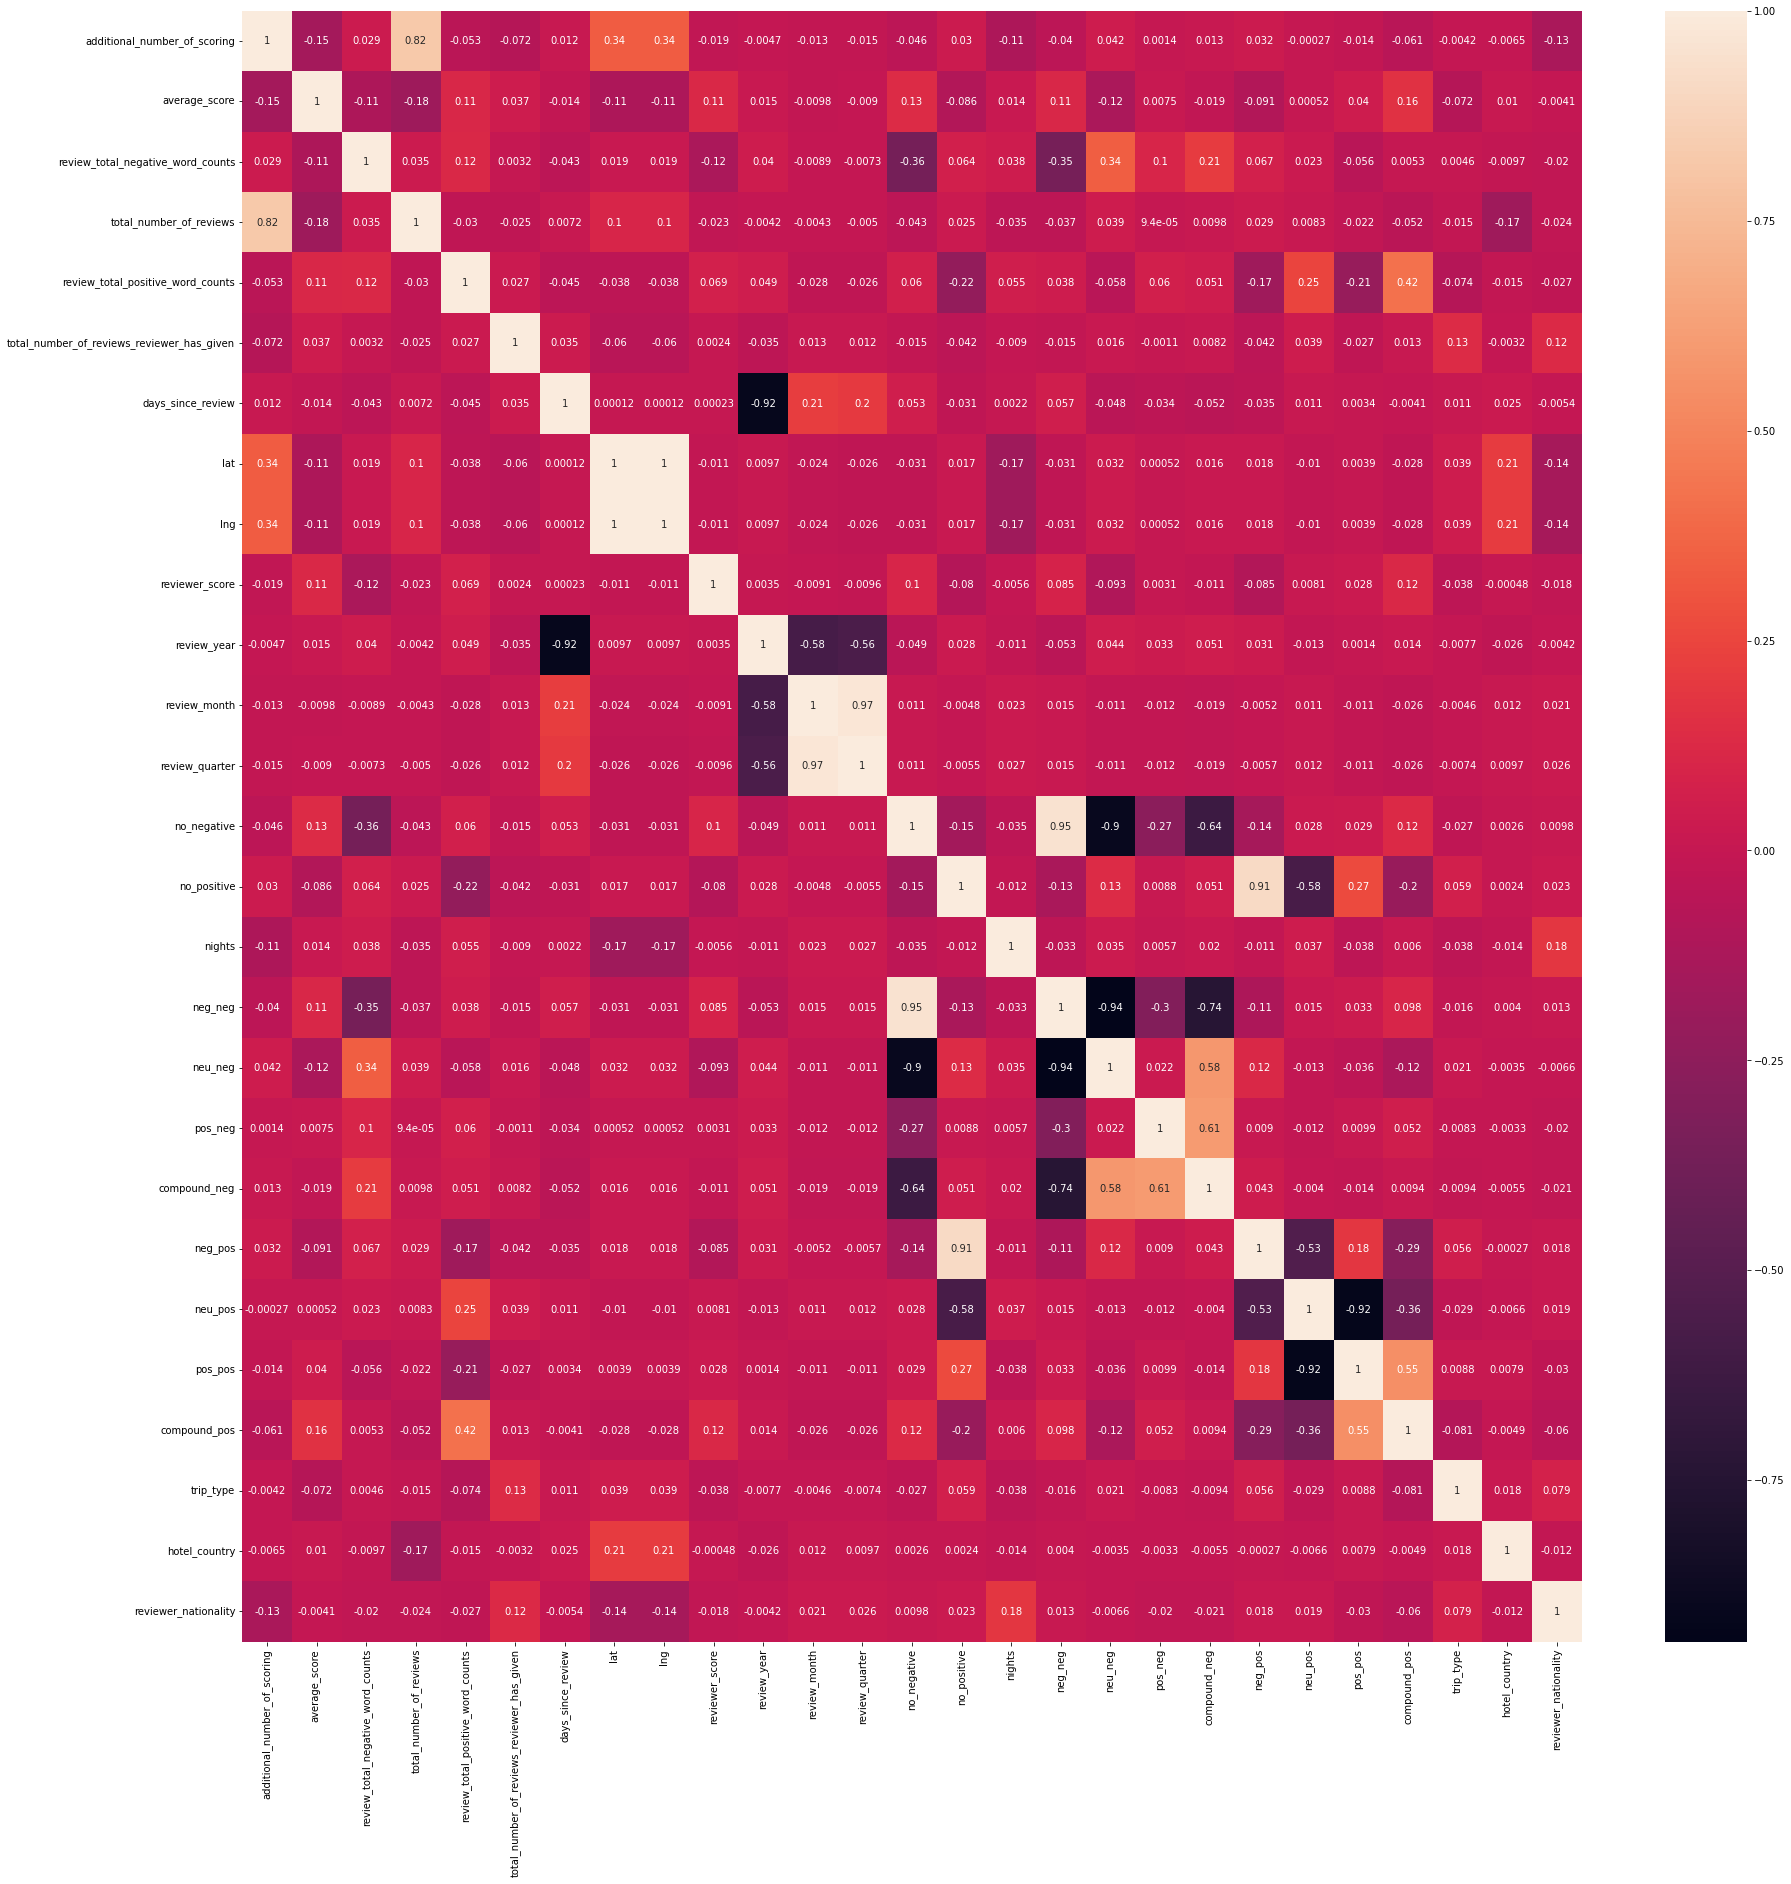

In [34]:
plt.rcParams['figure.figsize'] = (30,30)
sns.heatmap(data.drop(['sample'], axis=1).corr(), annot=True)

In [35]:
data.drop('additional_number_of_scoring', axis = 1, inplace=True)

In [36]:
# Теперь выделим тестовую часть
train_data = data.query('sample == 1').drop(['sample'], axis=1)
test_data = data.query('sample == 0').drop(['sample'], axis=1)

y = train_data.reviewer_score.values            # наш таргет
X = train_data.drop(['reviewer_score'], axis=1)

In [37]:
# Воспользуемся специальной функцие train_test_split для разбивки тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

<AxesSubplot:>

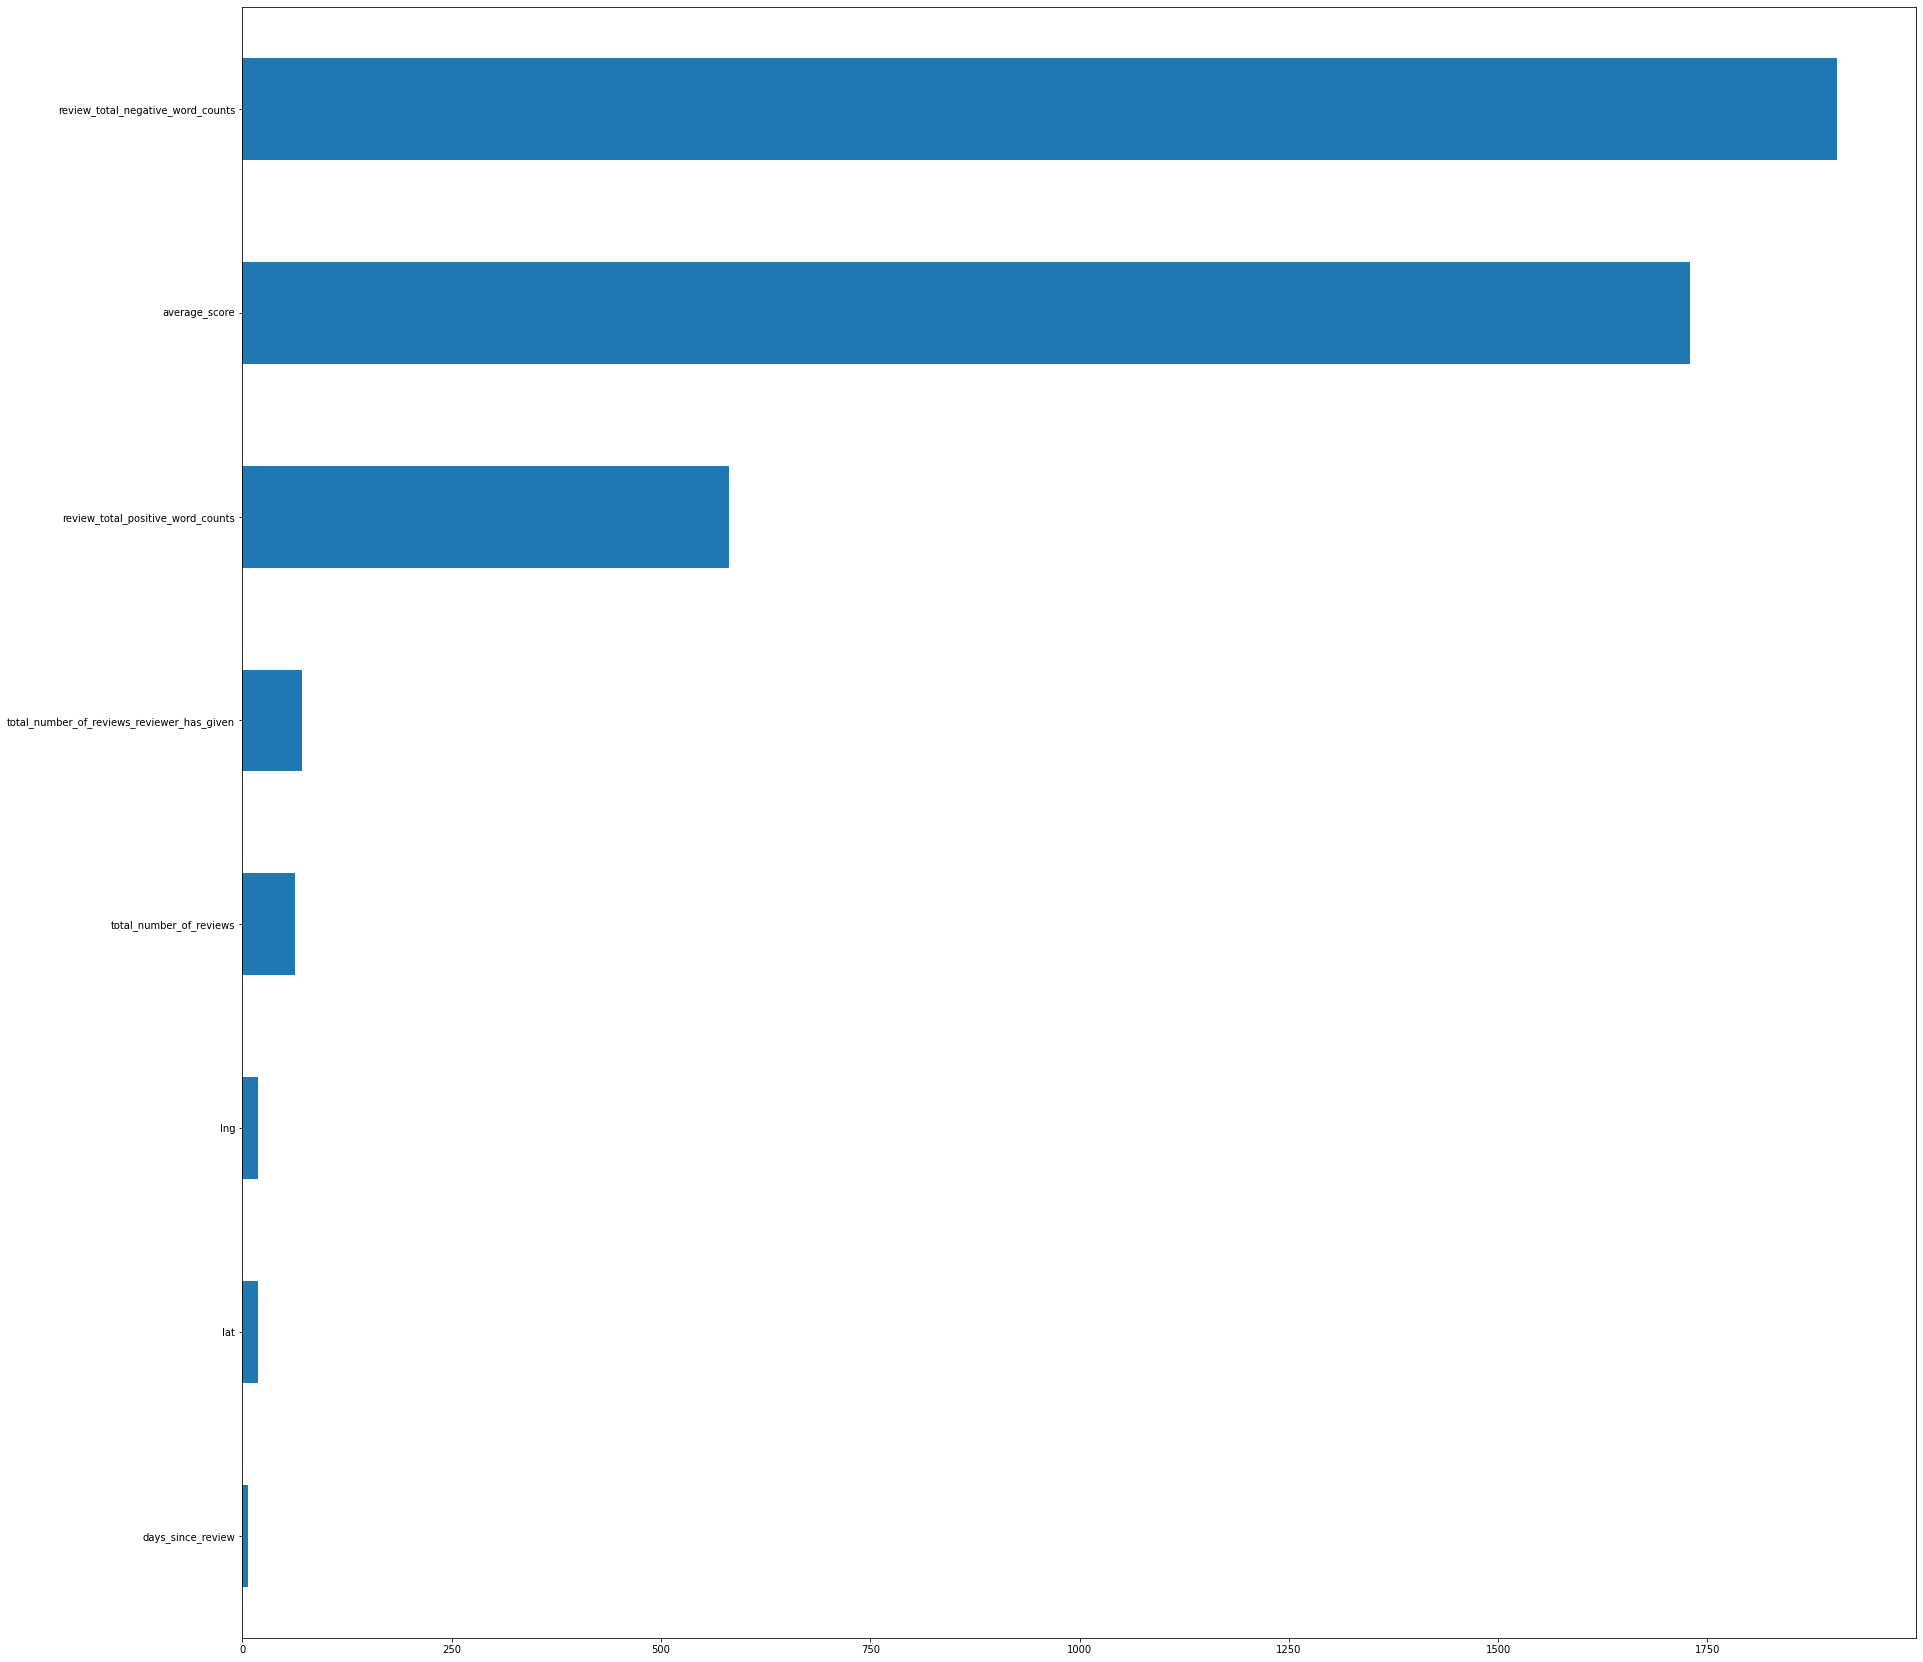

In [38]:
from sklearn.feature_selection import f_classif

num_cols = ['average_score', 'review_total_negative_word_counts', 'total_number_of_reviews', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'days_since_review', 'lat', 'lng']
stats, _ = f_classif(X[num_cols], y)
imp_num = pd.Series(stats, index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

# 6. Обучение модели

In [39]:
# проверяем
test_data.shape, train_data.shape, X.shape, X_train.shape, X_test.shape

((128935, 26), (386496, 26), (386496, 25), (309196, 25), (77300, 25))

In [40]:
# Импортируем необходимые библиотеки:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

In [41]:
# Создаём модель (НАСТРОЙКИ НЕ ТРОГАЕМ)
model = RandomForestRegressor(n_estimators=100, verbose=1, n_jobs=-1, random_state=RANDOM_SEED)

In [42]:
# Обучаем модель на тестовом наборе данных
model.fit(X_train, y_train)

# Используем обученную модель для предсказания рейтинга ресторанов в тестовой выборке.
# Предсказанные значения записываем в переменную y_pred
y_pred = model.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  3.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.8s finished


In [43]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они в среднем отличаются
# Метрика называется Mean Absolute Error (MAE) и показывает среднее отклонение предсказанных значений от фактических.
print('MAPE:', metrics.mean_absolute_error(y_test, y_pred))

MAPE: 0.8763373986632167


<AxesSubplot:>

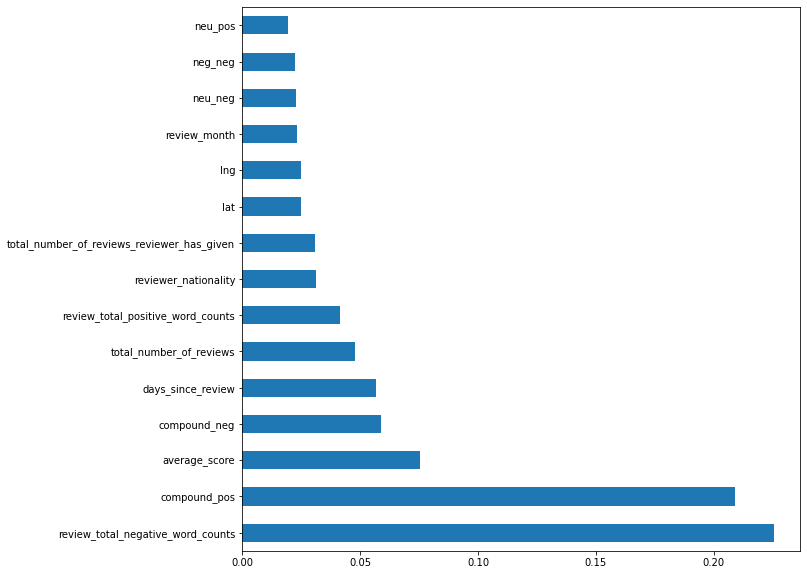

In [44]:
# в RandomForestRegressor есть возможность вывести самые важные признаки для модели
plt.rcParams['figure.figsize'] = (10,10)
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).plot(kind='barh')

In [45]:
test_data.sample(10)

,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,days_since_review,lat,lng,reviewer_score,review_year,...,neu_neg,pos_neg,compound_neg,neg_pos,neu_pos,pos_pos,compound_pos,trip_type,hotel_country,reviewer_nationality
128374,8.2,0,1330,9,19,473,51.514707,51.514707,0.0,2016,...,0.000,0.000,-0.7096,0.000,0.432,0.568,0.8360,1,4,1
66347,7.7,135,2667,39,1,367,48.214941,48.214941,0.0,2016,...,0.761,0.054,-0.9551,0.234,0.722,0.044,-0.8471,1,6,1
50416,7.6,28,4646,41,2,331,41.379205,41.379205,0.0,2016,...,1.000,0.000,0.0000,0.095,0.687,0.218,0.4480,1,3,1
113300,7.8,48,883,9,1,5,41.374703,41.374703,0.0,2017,...,0.782,0.000,-0.8531,0.000,0.723,0.277,0.3182,1,3,95
41256,8.7,9,7491,12,1,485,51.510841,51.510841,0.0,2016,...,0.795,0.000,-0.2023,0.000,0.491,0.509,0.8074,1,4,1
4622,8.6,25,4593,34,33,591,52.370247,52.370247,0.0,2015,...,0.607,0.169,-0.3919,0.000,0.655,0.345,0.9214,1,2,8
6226,8.1,5,1161,53,5,283,51.518856,51.518856,0.0,2016,...,0.351,0.649,0.5719,0.000,0.673,0.327,0.9699,1,4,50
114908,9.3,0,769,32,1,436,51.518918,51.518918,0.0,2016,...,0.000,0.000,-0.7096,0.000,0.661,0.339,0.9153,1,4,1
19813,8.1,57,1042,9,1,660,51.535760,51.535760,0.0,2015,...,0.721,0.172,0.4670,0.000,1.000,0.000,0.0000,1,4,1
28988,8.4,6,4117,42,1,149,51.513930,51.513930,0.0,2017,...,0.345,0.655,0.6908,0.109,0.655,0.236,0.8316,1,4,1


In [46]:
test_data = test_data.drop(['reviewer_score'], axis=1)

In [47]:
sample_submission

,reviewer_score,id
0,1,488440
1,10,274649
2,3,374688
3,10,404352
4,9,451596
...,...,...
128930,7,495812
128931,1,315577
128932,3,511968
128933,6,303386


In [48]:
predict_submission = model.predict(test_data)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.9s finished


In [49]:
predict_submission

array([8.57 , 7.467, 8.925, ..., 8.218, 9.496, 7.547])

In [50]:
list(sample_submission)

['reviewer_score', 'id']

In [51]:
sample_submission['reviewer_score'] = predict_submission
sample_submission.to_csv('submission.csv', index=False)
sample_submission.head(10)

,reviewer_score,id
0,8.570,488440
1,7.467,274649
2,8.925,374688
3,9.632,404352
4,9.550,451596
5,8.725,302161
6,7.526,317079
7,7.827,13963
8,8.667,159785
9,7.398,195089
